In [1]:
# %pip install matplotlib
# %pip install pandas

In [2]:
import pandas as pd

CSV_PATH = "./samples.csv"
df = pd.read_csv(CSV_PATH, index_col=False)

In [3]:
TIME_COL = "cycles"

# filter outliers
Q1 = df[TIME_COL].quantile(0.25)
Q3 = df[TIME_COL].quantile(0.75)
IQR = Q3 - Q1
LOW = Q1 - 1.5 * IQR
HIGH = Q3 + 1.5 * IQR
df = df[(df[TIME_COL] >= LOW) & (df[TIME_COL] <= HIGH)]

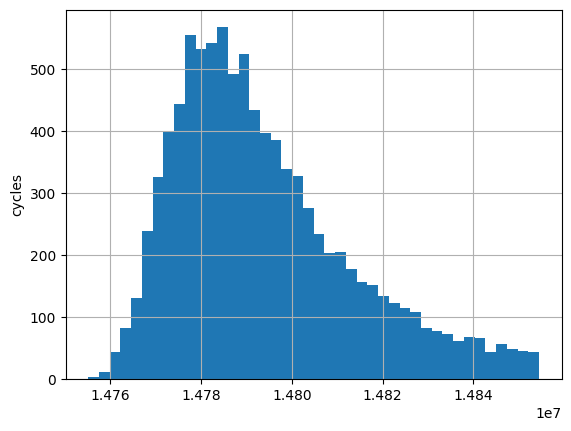

In [4]:
import matplotlib.pyplot as plt

N = len(df)
bw = 2 * IQR / (N ** (1/3))
bins = round((HIGH - LOW) / bw)

df[TIME_COL].hist(bins=bins)
plt.ylabel(TIME_COL)
plt.show()